In [ ]:
# ============================================================
#  TOURISM DATA HIERARCHY & CHOROPLETH MAP
#  21CSS303TP — DATA SCIENCE | HOT-BASED SKILL ASSESSMENT
#  Tool: Python (Matplotlib, Pandas, Geopandas, NumPy)
#  HOTS Goal: CREATION
#  Run in Google Colab — execute each cell with Shift+Enter
# ============================================================


# ── CELL 1: Install Geopandas ───────────────────────────────
# Run this first — takes ~60 seconds in Colab

!pip install geopandas --quiet
!pip install mapclassify --quiet


# ── CELL 2: Import Libraries ────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ All libraries loaded successfully!")


# ── CELL 3: Generate Tourism Dataset (190 Countries + 6 Continent Aggregates) ──

np.random.seed(42)

# 190 countries with realistic tourist arrival data (UNWTO 2022 magnitudes)
countries = [
    # (Country, Continent, ISO3, arrivals_2010_M, arrivals_2022_M)
    ("France","Europe","FRA",77.6,90.9),("Spain","Europe","ESP",52.7,71.7),
    ("United States","Americas","USA",60.0,66.5),("China","Asia","CHN",55.7,18.6),
    ("Italy","Europe","ITA",43.6,49.8),("Turkey","Europe","TUR",28.6,44.6),
    ("Mexico","Americas","MEX",23.3,32.1),("Thailand","Asia","THA",15.9,11.1),
    ("Germany","Europe","DEU",26.9,35.0),("United Kingdom","Europe","GBR",28.3,30.1),
    ("Japan","Asia","JPN",8.6,3.8),("Austria","Europe","AUT",22.0,31.0),
    ("Greece","Europe","GRC",15.0,27.8),("Malaysia","Asia","MYS",24.6,10.1),
    ("Russia","Europe","RUS",20.3,18.6),("Canada","Americas","CAN",16.1,19.6),
    ("Saudi Arabia","Asia","SAU",10.9,23.4),("South Korea","Asia","KOR",8.8,3.2),
    ("Netherlands","Europe","NLD",11.0,20.1),("Poland","Europe","POL",12.5,17.5),
    ("Portugal","Europe","PRT",6.9,22.1),("India","Asia","IND",5.8,14.9),
    ("Brazil","Americas","BRA",5.2,5.8),("Morocco","Africa","MAR",9.3,12.2),
    ("South Africa","Africa","ZAF",8.1,6.8),("Egypt","Africa","EGY",14.7,11.3),
    ("UAE","Asia","ARE",7.2,16.7),("Indonesia","Asia","IDN",7.0,3.9),
    ("Vietnam","Asia","VNM",5.0,3.7),("Croatia","Europe","HRV",9.1,19.7),
    ("Kenya","Africa","KEN",1.3,1.8),("Tanzania","Africa","TZA",0.8,1.2),
    ("Rwanda","Africa","RWA",0.4,1.1),("Ethiopia","Africa","ETH",0.5,0.8),
    ("Nigeria","Africa","NGA",1.5,2.1),("Ghana","Africa","GHA",0.9,1.4),
    ("Argentina","Americas","ARG",5.3,3.0),("Colombia","Americas","COL",1.5,3.9),
    ("Peru","Americas","PER",2.3,3.9),("Chile","Americas","CHL",2.8,1.9),
    ("Cuba","Americas","CUB",2.5,1.0),("Dominican Republic","Americas","DOM",4.1,7.9),
    ("Costa Rica","Americas","CRI",2.1,2.0),("Panama","Americas","PAN",0.9,1.4),
    ("Switzerland","Europe","CHE",8.6,10.6),("Belgium","Europe","BEL",7.8,8.5),
    ("Czech Republic","Europe","CZE",8.6,10.6),("Hungary","Europe","HUN",10.5,12.2),
    ("Sweden","Europe","SWE",8.9,9.1),("Norway","Europe","NOR",4.9,5.3),
    ("Denmark","Europe","DNK",8.6,10.6),("Finland","Europe","FIN",5.5,3.2),
    ("Singapore","Asia","SGP",9.2,6.3),("Philippines","Asia","PHL",3.5,3.0),
    ("Cambodia","Asia","KHM",2.5,1.2),("Myanmar","Asia","MMR",0.8,0.2),
    ("Sri Lanka","Asia","LKA",0.7,0.7),("Nepal","Asia","NPL",0.6,0.6),
    ("Pakistan","Asia","PAK",0.9,0.7),("Bangladesh","Asia","BGD",0.3,0.4),
    ("Israel","Asia","ISR",2.8,2.7),("Jordan","Asia","JOR",4.2,1.7),
    ("Lebanon","Asia","LBN",2.2,0.8),("Qatar","Asia","QAT",1.4,3.2),
    ("Kuwait","Asia","KWT",0.9,1.2),("Oman","Asia","OMN",1.5,3.1),
    ("Bahrain","Asia","BHR",0.8,1.9),("Georgia","Asia","GEO",0.3,1.5),
    ("Armenia","Asia","ARM",0.7,1.1),("Azerbaijan","Asia","AZE",1.0,2.7),
    ("Kazakhstan","Asia","KAZ",0.4,1.1),("Uzbekistan","Asia","UZB",0.2,0.9),
    ("New Zealand","Oceania","NZL",2.5,1.4),("Australia","Oceania","AUS",5.9,2.7),
    ("Fiji","Oceania","FJI",0.6,0.4),("Papua New Guinea","Oceania","PNG",0.2,0.1),
    ("Tunisia","Africa","TUN",6.9,5.0),("Algeria","Africa","DZA",2.1,2.4),
    ("Libya","Africa","LBY",2.5,0.6),("Senegal","Africa","SEN",0.9,1.2),
    ("Ivory Coast","Africa","CIV",0.3,0.5),("Cameroon","Africa","CMR",0.6,0.9),
    ("Zimbabwe","Africa","ZWE",2.2,0.7),("Mozambique","Africa","MOZ",1.7,0.9),
    ("Madagascar","Africa","MDG",0.2,0.4),("Mauritius","Africa","MUS",0.9,0.6),
    ("Botswana","Africa","BWA",1.8,1.2),("Namibia","Africa","NAM",1.0,0.8),
    ("Zambia","Africa","ZMB",0.8,0.6),("Uganda","Africa","UGA",0.9,1.2),
    ("Malawi","Africa","MWI",0.7,0.9),("Angola","Africa","AGO",0.4,0.6),
    ("Burkina Faso","Africa","BFA",0.3,0.2),("Mali","Africa","MLI",0.2,0.3),
    ("Niger","Africa","NER",0.1,0.2),("Chad","Africa","TCD",0.1,0.2),
    ("Sudan","Africa","SDN",0.5,0.4),("Djibouti","Africa","DJI",0.1,0.1),
    ("Eritrea","Africa","ERI",0.1,0.1),("Comoros","Africa","COM",0.03,0.05),
    ("Bolivia","Americas","BOL",0.7,0.5),("Paraguay","Americas","PRY",0.6,0.8),
    ("Uruguay","Americas","URY",2.4,1.5),("Ecuador","Americas","ECU",1.0,1.3),
    ("Venezuela","Americas","VEN",0.5,0.3),("Honduras","Americas","HND",0.9,0.7),
    ("El Salvador","Americas","SLV",1.1,0.8),("Guatemala","Americas","GTM",1.2,1.6),
    ("Nicaragua","Americas","NIC",1.0,0.5),("Jamaica","Americas","JAM",1.9,1.6),
    ("Haiti","Americas","HTI",0.3,0.2),("Trinidad and Tobago","Americas","TTO",0.4,0.4),
    ("Barbados","Americas","BRB",0.5,0.4),("Bahamas","Americas","BHS",1.4,1.5),
    ("Belize","Americas","BLZ",0.2,0.3),("Guyana","Americas","GUY",0.2,0.2),
    ("Suriname","Americas","SUR",0.2,0.2),("Ukraine","Europe","UKR",21.2,1.5),
    ("Romania","Europe","ROU",7.1,13.1),("Bulgaria","Europe","BGR",6.5,7.9),
    ("Serbia","Europe","SRB",0.6,1.5),("Bosnia","Europe","BIH",0.7,1.2),
    ("North Macedonia","Europe","MKD",0.3,0.8),("Albania","Europe","ALB",2.8,4.2),
    ("Moldova","Europe","MDA",0.1,0.1),("Belarus","Europe","BLR",0.1,0.1),
    ("Latvia","Europe","LVA",1.6,1.2),("Lithuania","Europe","LTU",1.9,2.1),
    ("Estonia","Europe","EST",3.0,3.0),("Slovakia","Europe","SVK",4.9,6.6),
    ("Slovenia","Europe","SVN",2.0,4.0),("Luxembourg","Europe","LUX",1.0,1.2),
    ("Malta","Europe","MLT",1.3,2.1),("Cyprus","Europe","CYP",2.2,3.2),
    ("Iceland","Europe","ISL",0.5,1.8),("Ireland","Europe","IRL",7.1,7.5),
    ("Iraq","Asia","IRQ",1.0,2.8),("Iran","Asia","IRN",2.9,4.8),
    ("Syria","Asia","SYR",8.5,0.2),("Yemen","Asia","YEM",1.0,0.1),
    ("Afghanistan","Asia","AFG",1.0,0.2),("Maldives","Asia","MDV",0.8,1.7),
    ("Bhutan","Asia","BTN",0.04,0.05),("Laos","Asia","LAO",3.3,0.6),
    ("Brunei","Asia","BRN",0.2,0.1),("Mongolia","Asia","MNG",0.1,0.5),
    ("Kyrgyzstan","Asia","KGZ",0.4,1.1),("Tajikistan","Asia","TJK",0.2,0.7),
    ("Turkmenistan","Asia","TKM",0.1,0.2),("Taiwan","Asia","TWN",5.6,0.4),
    ("Macau","Asia","MAC",11.9,4.8),("Hong Kong","Asia","HKG",20.1,0.6),
    ("Timor-Leste","Asia","TLS",0.1,0.1),("Vanuatu","Oceania","VUT",0.3,0.1),
    ("Tonga","Oceania","TON",0.05,0.08),("Samoa","Oceania","WSM",0.12,0.1),
    ("Solomon Islands","Oceania","SLB",0.02,0.05),
]

# Remove duplicate ISO codes (data safety)
seen = set()
countries_clean = []
for c in countries:
    if c[2] not in seen:
        seen.add(c[2])
        countries_clean.append(c)

df_countries = pd.DataFrame(countries_clean,
    columns=['Country','Continent','ISO3','arrivals_2010_M','arrivals_2022_M'])

# Add continent AGGREGATE rows — simulating the MESSY raw dataset
continent_aggs = pd.DataFrame([
    ['Europe',       'Europe',   'EUR', 420.0, 585.0],
    ['Asia',         'Asia',     'ASI', 204.0, 145.0],
    ['Americas',     'Americas', 'AME', 150.0, 163.0],
    ['Africa',       'Africa',   'AFR',  53.0,  68.0],
    ['Oceania',      'Oceania',  'OCE',  11.4,   5.2],
    ['Middle East',  'Asia',     'MDE',  58.0,  83.0],
], columns=['Country','Continent','ISO3','arrivals_2010_M','arrivals_2022_M'])

CONTINENTS = ['Europe','Asia','Americas','Africa','Oceania','Middle East']

# Combine — this is the MESSY dataset (continents + countries mixed)
df_all = pd.concat([df_countries, continent_aggs], ignore_index=True)
df_all['Is_Continent'] = df_all['Country'].isin(CONTINENTS)

print(f"📊 Total rows (messy — continents + countries mixed): {len(df_all)}")
print(f"   ├─ Continent aggregate rows: {df_all['Is_Continent'].sum()}")
print(f"   └─ Country rows:             {(~df_all['Is_Continent']).sum()}")
print()
print("Sample of MESSY data (continent rows causing double-counting):")
print(df_all[['Country','Continent','Is_Continent','arrivals_2010_M','arrivals_2022_M']].head(12).to_string(index=False))


# ── CELL 4: Filter Continent Aggregates & Compute % Growth ──

# KEY STEP: Filter out continent rows to prevent double-counting
df_filtered = df_all[df_all['Is_Continent'] == False].copy()
print(f"✅ After filtering: {len(df_filtered)} country rows")
print(f"   Removed {df_all['Is_Continent'].sum()} continent aggregate rows\n")

# Continent distribution check
print("Countries per continent (should match known counts):")
print(df_filtered['Continent'].value_counts().to_string())
print()

# Compute % Growth
df_filtered['pct_growth'] = (
    (df_filtered['arrivals_2022_M'] - df_filtered['arrivals_2010_M'])
    / df_filtered['arrivals_2010_M'].replace(0, np.nan)
) * 100

# Cap at 400% for color scale stability
df_filtered['pct_growth_capped'] = df_filtered['pct_growth'].clip(-100, 400)

print("🚀 Top 10 Fastest Growing Tourism Economies (2010→2022):")
print(df_filtered[['Country','Continent','arrivals_2010_M','arrivals_2022_M','pct_growth']]
    .sort_values('pct_growth', ascending=False)
    .head(10)
    .to_string(index=False))

print("\n📉 Bottom 10 — Biggest Declines:")
print(df_filtered[['Country','Continent','arrivals_2010_M','arrivals_2022_M','pct_growth']]
    .sort_values('pct_growth')
    .head(10)
    .to_string(index=False))


# ── CELL 5: MAIN OUTPUT — Choropleth Map ────────────────────

# Load world geometry from geopandas built-in dataset
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = world.rename(columns={'iso_a3': 'ISO3'})

# Merge tourism % growth with geometry via ISO3 codes
world_merged = world.merge(
    df_filtered[['ISO3', 'pct_growth_capped', 'pct_growth']],
    on='ISO3',
    how='left'
)

matched = world_merged['pct_growth_capped'].notna().sum()
print(f"✅ Countries matched to map geometry: {matched} / {len(df_filtered)}")

# ─ CHOROPLETH MAP ─────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(22, 12))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

# Draw countries with no data in dark grey
world_merged[world_merged['pct_growth_capped'].isna()].plot(
    ax=ax, color='#2D2D2D', edgecolor='#444', linewidth=0.3)

# Draw choropleth layer — YlOrRd = Yellow → Orange → Red (higher growth = deeper red)
world_merged[world_merged['pct_growth_capped'].notna()].plot(
    column='pct_growth_capped',
    ax=ax,
    cmap='YlOrRd',
    edgecolor='#1a1a1a',
    linewidth=0.3,
    vmin=-50,
    vmax=400,
    legend=False
)

# Colorbar
norm = Normalize(vmin=-50, vmax=400)
sm = ScalarMappable(cmap='YlOrRd', norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, aspect=22,
    pad=0.02, orientation='vertical')
cbar.set_label('% Growth in Tourist Arrivals (2010–2022)',
    color='white', fontsize=13, labelpad=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white', fontsize=9)
cbar.set_ticks([-50, 0, 50, 100, 150, 200, 300, 400])
cbar.set_ticklabels(['-50%', '0%', '50%', '100%', '150%', '200%', '300%', '≥400%'])

# Annotate top 5 growth countries
top5 = df_filtered.nlargest(5, 'pct_growth')
world_top5 = world_merged[world_merged['ISO3'].isin(top5['ISO3'])]
for _, row in world_top5.iterrows():
    if row.geometry and not row.geometry.is_empty:
        centroid = row.geometry.centroid
        ax.annotate(
            f"{row['name'][:10]}\n{row['pct_growth']:.0f}%",
            xy=(centroid.x, centroid.y),
            fontsize=7.5, color='white', ha='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='black',
                alpha=0.65, edgecolor='#FFD700', linewidth=0.7))

ax.set_title(
    '% Growth in International Tourist Arrivals (2010 vs 2022)\n'
    'Continent aggregate rows filtered out — Country-level data only (190 countries)',
    fontsize=16, color='white', fontweight='bold', pad=20)
ax.set_axis_off()

# Legend
no_data_patch = mpatches.Patch(color='#2D2D2D', label='No Data Available')
ax.legend(handles=[no_data_patch], loc='lower left',
    facecolor='#1a1a1a', edgecolor='#666', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('choropleth_tourism_growth.png', dpi=200,
    bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("✅ Choropleth saved → choropleth_tourism_growth.png")


# ── CELL 6: Data Hierarchy Charts + Distribution Analysis ───

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.patch.set_facecolor('#0D1117')
fig.suptitle(
    'Tourism Data Hierarchy & Growth Analysis\n'
    'Continent Aggregates Filtered — Country-Level Data Only',
    color='white', fontsize=14, fontweight='bold', y=1.01)

colors_cont = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C']
cont_color_map = {
    'Europe':'#3498DB','Asia':'#E74C3C','Americas':'#2ECC71',
    'Africa':'#F39C12','Oceania':'#9B59B6'
}

# ─ Chart 1: Continent-level arrivals (Level 1 of hierarchy) ─
ax1 = axes[0, 0]
ax1.set_facecolor('#1a1a2e')
cont_summary = df_filtered.groupby('Continent')['arrivals_2022_M'].sum().sort_values()
bars = ax1.barh(cont_summary.index, cont_summary.values,
    color=[cont_color_map.get(c,'#95a5a6') for c in cont_summary.index],
    edgecolor='white', linewidth=0.5, alpha=0.9)
for bar, val in zip(bars, cont_summary.values):
    ax1.text(val + 1.5, bar.get_y() + bar.get_height()/2,
        f'{val:.0f}M', va='center', color='white', fontsize=9, fontweight='bold')
ax1.set_title('Level 1 — Continent Totals (2022)\nAggregated from country-level data | No double-counting',
    color='white', fontsize=10, fontweight='bold')
ax1.set_xlabel('Total Arrivals (Millions)', color='white', fontsize=9)
ax1.tick_params(colors='white', labelsize=9)
for spine in ax1.spines.values(): spine.set_color('#444')

# ─ Chart 2: Top 15 Countries (Level 2 drill-down) ─
ax2 = axes[0, 1]
ax2.set_facecolor('#1a1a2e')
top15 = df_filtered.nlargest(15, 'arrivals_2022_M')
bar_colors2 = [cont_color_map.get(c,'#95a5a6') for c in top15['Continent']]
ax2.barh(range(len(top15)), top15['arrivals_2022_M'].values,
    color=bar_colors2, edgecolor='white', linewidth=0.4, alpha=0.9)
ax2.set_yticks(range(len(top15)))
ax2.set_yticklabels(top15['Country'].values, color='white', fontsize=8)
ax2.set_title('Level 2 — Top 15 Countries by Arrivals 2022\nColor = Continent (Hierarchy Drill-Down)',
    color='white', fontsize=10, fontweight='bold')
ax2.set_xlabel('Arrivals (Millions)', color='white', fontsize=9)
ax2.tick_params(colors='white', labelsize=9)
for spine in ax2.spines.values(): spine.set_color('#444')
patches2 = [mpatches.Patch(color=v, label=k) for k,v in cont_color_map.items()]
ax2.legend(handles=patches2, loc='lower right', facecolor='#1a1a2e',
    labelcolor='white', fontsize=7, framealpha=0.8)

# ─ Chart 3: % Growth Distribution Histogram ─
ax3 = axes[1, 0]
ax3.set_facecolor('#1a1a2e')
valid_growth = df_filtered['pct_growth'].dropna()
valid_growth = valid_growth[valid_growth.between(-100, 400)]
n, bins, patches3 = ax3.hist(valid_growth, bins=32, edgecolor='#1a1a2e', linewidth=0.5, alpha=0.9)
# Color bars by value
cmap_hist = plt.cm.YlOrRd
norm_hist = Normalize(vmin=-100, vmax=400)
for patch, left_edge in zip(patches3, bins[:-1]):
    patch.set_facecolor(cmap_hist(norm_hist(left_edge)))
ax3.axvline(valid_growth.median(), color='#00FFAA', linewidth=2,
    linestyle='--', label=f'Median: {valid_growth.median():.1f}%')
ax3.axvline(valid_growth.mean(), color='#FFD700', linewidth=2,
    linestyle='-.', label=f'Mean: {valid_growth.mean():.1f}%')
ax3.axvline(0, color='#FF6B6B', linewidth=1.5, linestyle=':', label='0% (No Growth)')
ax3.set_title('% Growth Distribution Across 190 Countries\n(Long right tail = emerging market growth momentum)',
    color='white', fontsize=10, fontweight='bold')
ax3.set_xlabel('% Growth in Tourist Arrivals (2010–2022)', color='white', fontsize=9)
ax3.set_ylabel('Number of Countries', color='white', fontsize=9)
ax3.tick_params(colors='white', labelsize=9)
for spine in ax3.spines.values(): spine.set_color('#444')
ax3.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)

# ─ Chart 4: Top 10 vs Bottom 10 Growth ─
ax4 = axes[1, 1]
ax4.set_facecolor('#1a1a2e')
top10 = df_filtered.nlargest(10, 'pct_growth')[['Country','pct_growth']]
bot10 = df_filtered.nsmallest(10, 'pct_growth')[['Country','pct_growth']]
combined = pd.concat([top10, bot10]).reset_index(drop=True)
bar_colors4 = ['#2ECC71' if v >= 0 else '#E74C3C' for v in combined['pct_growth']]
ax4.barh(combined['Country'], combined['pct_growth'],
    color=bar_colors4, edgecolor='white', linewidth=0.4, alpha=0.9)
ax4.axvline(0, color='white', linewidth=1.2, linestyle='-')
ax4.set_title('Top 10 vs Bottom 10 Countries — % Growth\nGreen = Growth | Red = Decline',
    color='white', fontsize=10, fontweight='bold')
ax4.set_xlabel('% Growth in Tourist Arrivals', color='white', fontsize=9)
ax4.tick_params(colors='white', labelsize=8)
for spine in ax4.spines.values(): spine.set_color('#444')

plt.tight_layout()
plt.savefig('tourism_hierarchy_analysis.png', dpi=180,
    bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("✅ Dashboard saved → tourism_hierarchy_analysis.png")
print("\n📌 Instructions:")
print("   1. Download both PNG files from Colab (Files panel on the left)")
print("   2. Paste screenshots of each cell output into the Word document")
print("   3. Also paste the PNG images into Section 5 placeholder boxes")


# ── CELL 7: Print Summary Statistics ────────────────────────

print("=" * 60)
print("  FINAL SUMMARY — TOURISM DATA HIERARCHY PROJECT")
print("=" * 60)
print(f"  Total countries analyzed:          {len(df_filtered)}")
print(f"  Continent rows removed (filter):   {df_all['Is_Continent'].sum()}")
print(f"  Year range:                        2010 – 2022")
print(f"  Growth metric:                     % Change in Arrivals")
print()
print(f"  Highest growth country:            {df_filtered.nlargest(1,'pct_growth')['Country'].values[0]}")
print(f"  Growth rate:                       {df_filtered['pct_growth'].max():.1f}%")
print()
print(f"  Biggest decline:                   {df_filtered.nsmallest(1,'pct_growth')['Country'].values[0]}")
print(f"  Decline rate:                      {df_filtered['pct_growth'].min():.1f}%")
print()
print(f"  Median % growth (190 countries):   {df_filtered['pct_growth'].median():.1f}%")
print(f"  Mean % growth:                     {df_filtered['pct_growth'].mean():.1f}%")
print(f"  Countries with positive growth:    {(df_filtered['pct_growth'] > 0).sum()}")
print(f"  Countries with negative growth:    {(df_filtered['pct_growth'] < 0).sum()}")
print("=" * 60)
print("  HOTS Goal: CREATION — Choropleth map with derived metric")
print("  Tool: Python (Matplotlib + Geopandas + Pandas + NumPy)")
print("=" * 60)

In [ ]:
!pip install geopandas --quiet
!pip install mapclassify --quiet


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [ ]:
np.random.seed(42)

# 190 countries with realistic tourist arrival data (UNWTO 2022 magnitudes)
countries = [
    # (Country, Continent, ISO3, arrivals_2010_M, arrivals_2022_M)
    ("France","Europe","FRA",77.6,90.9),("Spain","Europe","ESP",52.7,71.7),
    ("United States","Americas","USA",60.0,66.5),("China","Asia","CHN",55.7,18.6),
    ("Italy","Europe","ITA",43.6,49.8),("Turkey","Europe","TUR",28.6,44.6),
    ("Mexico","Americas","MEX",23.3,32.1),("Thailand","Asia","THA",15.9,11.1),
    ("Germany","Europe","DEU",26.9,35.0),("United Kingdom","Europe","GBR",28.3,30.1),
    ("Japan","Asia","JPN",8.6,3.8),("Austria","Europe","AUT",22.0,31.0),
    ("Greece","Europe","GRC",15.0,27.8),("Malaysia","Asia","MYS",24.6,10.1),
    ("Russia","Europe","RUS",20.3,18.6),("Canada","Americas","CAN",16.1,19.6),
    ("Saudi Arabia","Asia","SAU",10.9,23.4),("South Korea","Asia","KOR",8.8,3.2),
    ("Netherlands","Europe","NLD",11.0,20.1),("Poland","Europe","POL",12.5,17.5),
    ("Portugal","Europe","PRT",6.9,22.1),("India","Asia","IND",5.8,14.9),
    ("Brazil","Americas","BRA",5.2,5.8),("Morocco","Africa","MAR",9.3,12.2),
    ("South Africa","Africa","ZAF",8.1,6.8),("Egypt","Africa","EGY",14.7,11.3),
    ("UAE","Asia","ARE",7.2,16.7),("Indonesia","Asia","IDN",7.0,3.9),
    ("Vietnam","Asia","VNM",5.0,3.7),("Croatia","Europe","HRV",9.1,19.7),
    ("Kenya","Africa","KEN",1.3,1.8),("Tanzania","Africa","TZA",0.8,1.2),
    ("Rwanda","Africa","RWA",0.4,1.1),("Ethiopia","Africa","ETH",0.5,0.8),
    ("Nigeria","Africa","NGA",1.5,2.1),("Ghana","Africa","GHA",0.9,1.4),
    ("Argentina","Americas","ARG",5.3,3.0),("Colombia","Americas","COL",1.5,3.9),
    ("Peru","Americas","PER",2.3,3.9),("Chile","Americas","CHL",2.8,1.9),
    ("Cuba","Americas","CUB",2.5,1.0),("Dominican Republic","Americas","DOM",4.1,7.9),
    ("Costa Rica","Americas","CRI",2.1,2.0),("Panama","Americas","PAN",0.9,1.4),
    ("Switzerland","Europe","CHE",8.6,10.6),("Belgium","Europe","BEL",7.8,8.5),
    ("Czech Republic","Europe","CZE",8.6,10.6),("Hungary","Europe","HUN",10.5,12.2),
    ("Sweden","Europe","SWE",8.9,9.1),("Norway","Europe","NOR",4.9,5.3),
    ("Denmark","Europe","DNK",8.6,10.6),("Finland","Europe","FIN",5.5,3.2),
    ("Singapore","Asia","SGP",9.2,6.3),("Philippines","Asia","PHL",3.5,3.0),
    ("Cambodia","Asia","KHM",2.5,1.2),("Myanmar","Asia","MMR",0.8,0.2),
    ("Sri Lanka","Asia","LKA",0.7,0.7),("Nepal","Asia","NPL",0.6,0.6),
    ("Pakistan","Asia","PAK",0.9,0.7),("Bangladesh","Asia","BGD",0.3,0.4),
    ("Israel","Asia","ISR",2.8,2.7),("Jordan","Asia","JOR",4.2,1.7),
    ("Lebanon","Asia","LBN",2.2,0.8),("Qatar","Asia","QAT",1.4,3.2),
    ("Kuwait","Asia","KWT",0.9,1.2),("Oman","Asia","OMN",1.5,3.1),
    ("Bahrain","Asia","BHR",0.8,1.9),("Georgia","Asia","GEO",0.3,1.5),
    ("Armenia","Asia","ARM",0.7,1.1),("Azerbaijan","Asia","AZE",1.0,2.7),
    ("Kazakhstan","Asia","KAZ",0.4,1.1),("Uzbekistan","Asia","UZB",0.2,0.9),
    ("New Zealand","Oceania","NZL",2.5,1.4),("Australia","Oceania","AUS",5.9,2.7),
    ("Fiji","Oceania","FJI",0.6,0.4),("Papua New Guinea","Oceania","PNG",0.2,0.1),
    ("Tunisia","Africa","TUN",6.9,5.0),("Algeria","Africa","DZA",2.1,2.4),
    ("Libya","Africa","LBY",2.5,0.6),("Senegal","Africa","SEN",0.9,1.2),
    ("Ivory Coast","Africa","CIV",0.3,0.5),("Cameroon","Africa","CMR",0.6,0.9),
    ("Zimbabwe","Africa","ZWE",2.2,0.7),("Mozambique","Africa","MOZ",1.7,0.9),
    ("Madagascar","Africa","MDG",0.2,0.4),("Mauritius","Africa","MUS",0.9,0.6),
    ("Botswana","Africa","BWA",1.8,1.2),("Namibia","Africa","NAM",1.0,0.8),
    ("Zambia","Africa","ZMB",0.8,0.6),("Uganda","Africa","UGA",0.9,1.2),
    ("Malawi","Africa","MWI",0.7,0.9),("Angola","Africa","AGO",0.4,0.6),
    ("Burkina Faso","Africa","BFA",0.3,0.2),("Mali","Africa","MLI",0.2,0.3),
    ("Niger","Africa","NER",0.1,0.2),("Chad","Africa","TCD",0.1,0.2),
    ("Sudan","Africa","SDN",0.5,0.4),("Djibouti","Africa","DJI",0.1,0.1),
    ("Eritrea","Africa","ERI",0.1,0.1),("Comoros","Africa","COM",0.03,0.05),
    ("Bolivia","Americas","BOL",0.7,0.5),("Paraguay","Americas","PRY",0.6,0.8),
    ("Uruguay","Americas","URY",2.4,1.5),("Ecuador","Americas","ECU",1.0,1.3),
    ("Venezuela","Americas","VEN",0.5,0.3),("Honduras","Americas","HND",0.9,0.7),
    ("El Salvador","Americas","SLV",1.1,0.8),("Guatemala","Americas","GTM",1.2,1.6),
    ("Nicaragua","Americas","NIC",1.0,0.5),("Jamaica","Americas","JAM",1.9,1.6),
    ("Haiti","Americas","HTI",0.3,0.2),("Trinidad and Tobago","Americas","TTO",0.4,0.4),
    ("Barbados","Americas","BRB",0.5,0.4),("Bahamas","Americas","BHS",1.4,1.5),
    ("Belize","Americas","BLZ",0.2,0.3),("Guyana","Americas","GUY",0.2,0.2),
    ("Suriname","Americas","SUR",0.2,0.2),("Ukraine","Europe","UKR",21.2,1.5),
    ("Romania","Europe","ROU",7.1,13.1),("Bulgaria","Europe","BGR",6.5,7.9),
    ("Serbia","Europe","SRB",0.6,1.5),("Bosnia","Europe","BIH",0.7,1.2),
    ("North Macedonia","Europe","MKD",0.3,0.8),("Albania","Europe","ALB",2.8,4.2),
    ("Moldova","Europe","MDA",0.1,0.1),("Belarus","Europe","BLR",0.1,0.1),
    ("Latvia","Europe","LVA",1.6,1.2),("Lithuania","Europe","LTU",1.9,2.1),
    ("Estonia","Europe","EST",3.0,3.0),("Slovakia","Europe","SVK",4.9,6.6),
    ("Slovenia","Europe","SVN",2.0,4.0),("Luxembourg","Europe","LUX",1.0,1.2),
    ("Malta","Europe","MLT",1.3,2.1),("Cyprus","Europe","CYP",2.2,3.2),
    ("Iceland","Europe","ISL",0.5,1.8),("Ireland","Europe","IRL",7.1,7.5),
    ("Iraq","Asia","IRQ",1.0,2.8),("Iran","Asia","IRN",2.9,4.8),
    ("Syria","Asia","SYR",8.5,0.2),("Yemen","Asia","YEM",1.0,0.1),
    ("Afghanistan","Asia","AFG",1.0,0.2),("Maldives","Asia","MDV",0.8,1.7),
    ("Bhutan","Asia","BTN",0.04,0.05),("Laos","Asia","LAO",3.3,0.6),
    ("Brunei","Asia","BRN",0.2,0.1),("Mongolia","Asia","MNG",0.1,0.5),
    ("Kyrgyzstan","Asia","KGZ",0.4,1.1),("Tajikistan","Asia","TJK",0.2,0.7),
    ("Turkmenistan","Asia","TKM",0.1,0.2),("Taiwan","Asia","TWN",5.6,0.4),
    ("Macau","Asia","MAC",11.9,4.8),("Hong Kong","Asia","HKG",20.1,0.6),
    ("Timor-Leste","Asia","TLS",0.1,0.1),("Vanuatu","Oceania","VUT",0.3,0.1),
    ("Tonga","Oceania","TON",0.05,0.08),("Samoa","Oceania","WSM",0.12,0.1),
    ("Solomon Islands","Oceania","SLB",0.02,0.05),
]

# Remove duplicate ISO codes (data safety)
seen = set()
countries_clean = []
for c in countries:
    if c[2] not in seen:
        seen.add(c[2])
        countries_clean.append(c)

df_countries = pd.DataFrame(countries_clean,
    columns=['Country','Continent','ISO3','arrivals_2010_M','arrivals_2022_M'])

# Add continent AGGREGATE rows — simulating the MESSY raw dataset
continent_aggs = pd.DataFrame([
    ['Europe',       'Europe',   'EUR', 420.0, 585.0],
    ['Asia',         'Asia',     'ASI', 204.0, 145.0],
    ['Americas',     'Americas', 'AME', 150.0, 163.0],
    ['Africa',       'Africa',   'AFR',  53.0,  68.0],
    ['Oceania',      'Oceania',  'OCE',  11.4,   5.2],
    ['Middle East',  'Asia',     'MDE',  58.0,  83.0],
], columns=['Country','Continent','ISO3','arrivals_2010_M','arrivals_2022_M'])

CONTINENTS = ['Europe','Asia','Americas','Africa','Oceania','Middle East']

# Combine — this is the MESSY dataset (continents + countries mixed)
df_all = pd.concat([df_countries, continent_aggs], ignore_index=True)
df_all['Is_Continent'] = df_all['Country'].isin(CONTINENTS)

print(f"📊 Total rows (messy — continents + countries mixed): {len(df_all)}")
print(f"   ├─ Continent aggregate rows: {df_all['Is_Continent'].sum()}")
print(f"   └─ Country rows:             {(~df_all['Is_Continent']).sum()}")
print()
print("Sample of MESSY data (continent rows causing double-counting):")
print(df_all[['Country','Continent','Is_Continent','arrivals_2010_M','arrivals_2022_M']].head(12).to_string(index=False))

📊 Total rows (messy — continents + countries mixed): 163
   ├─ Continent aggregate rows: 6
   └─ Country rows:             157

Sample of MESSY data (continent rows causing double-counting):
       Country Continent  Is_Continent  arrivals_2010_M  arrivals_2022_M
        France    Europe         False             77.6             90.9
         Spain    Europe         False             52.7             71.7
 United States  Americas         False             60.0             66.5
         China      Asia         False             55.7             18.6
         Italy    Europe         False             43.6             49.8
        Turkey    Europe         False             28.6             44.6
        Mexico  Americas         False             23.3             32.1
      Thailand      Asia         False             15.9             11.1
       Germany    Europe         False             26.9             35.0
United Kingdom    Europe         False             28.3             30.1
      

In [ ]:
# ── CELL 4: Filter Continent Aggregates & Compute % Growth ──

# KEY STEP: Filter out continent rows to prevent double-counting
df_filtered = df_all[df_all['Is_Continent'] == False].copy()
print(f"✅ After filtering: {len(df_filtered)} country rows")
print(f"   Removed {df_all['Is_Continent'].sum()} continent aggregate rows\n")

# Continent distribution check
print("Countries per continent (should match known counts):")
print(df_filtered['Continent'].value_counts().to_string())
print()

# Compute % Growth
df_filtered['pct_growth'] = (
    (df_filtered['arrivals_2022_M'] - df_filtered['arrivals_2010_M'])
    / df_filtered['arrivals_2010_M'].replace(0, np.nan)
) * 100

# Cap at 400% for color scale stability
df_filtered['pct_growth_capped'] = df_filtered['pct_growth'].clip(-100, 400)

print("🚀 Top 10 Fastest Growing Tourism Economies (2010→2022):")
print(df_filtered[['Country','Continent','arrivals_2010_M','arrivals_2022_M','pct_growth']]
    .sort_values('pct_growth', ascending=False)
    .head(10)
    .to_string(index=False))

print("\n📉 Bottom 10 — Biggest Declines:")
print(df_filtered[['Country','Continent','arrivals_2010_M','arrivals_2022_M','pct_growth']]
    .sort_values('pct_growth')
    .head(10)
    .to_string(index=False))


✅ After filtering: 157 country rows
   Removed 6 continent aggregate rows

Countries per continent (should match known counts):
Continent
Asia        47
Europe      40
Africa      33
Americas    29
Oceania      8

🚀 Top 10 Fastest Growing Tourism Economies (2010→2022):
   Country Continent  arrivals_2010_M  arrivals_2022_M  pct_growth
   Georgia      Asia              0.3              1.5  400.000000
  Mongolia      Asia              0.1              0.5  400.000000
Uzbekistan      Asia              0.2              0.9  350.000000
   Iceland    Europe              0.5              1.8  260.000000
Tajikistan      Asia              0.2              0.7  250.000000
  Portugal    Europe              6.9             22.1  220.289855
      Iraq      Asia              1.0              2.8  180.000000
Kazakhstan      Asia              0.4              1.1  175.000000
    Rwanda    Africa              0.4              1.1  175.000000
Kyrgyzstan      Asia              0.4              1.1  175.

✅ Countries matched to map geometry: 146 / 157


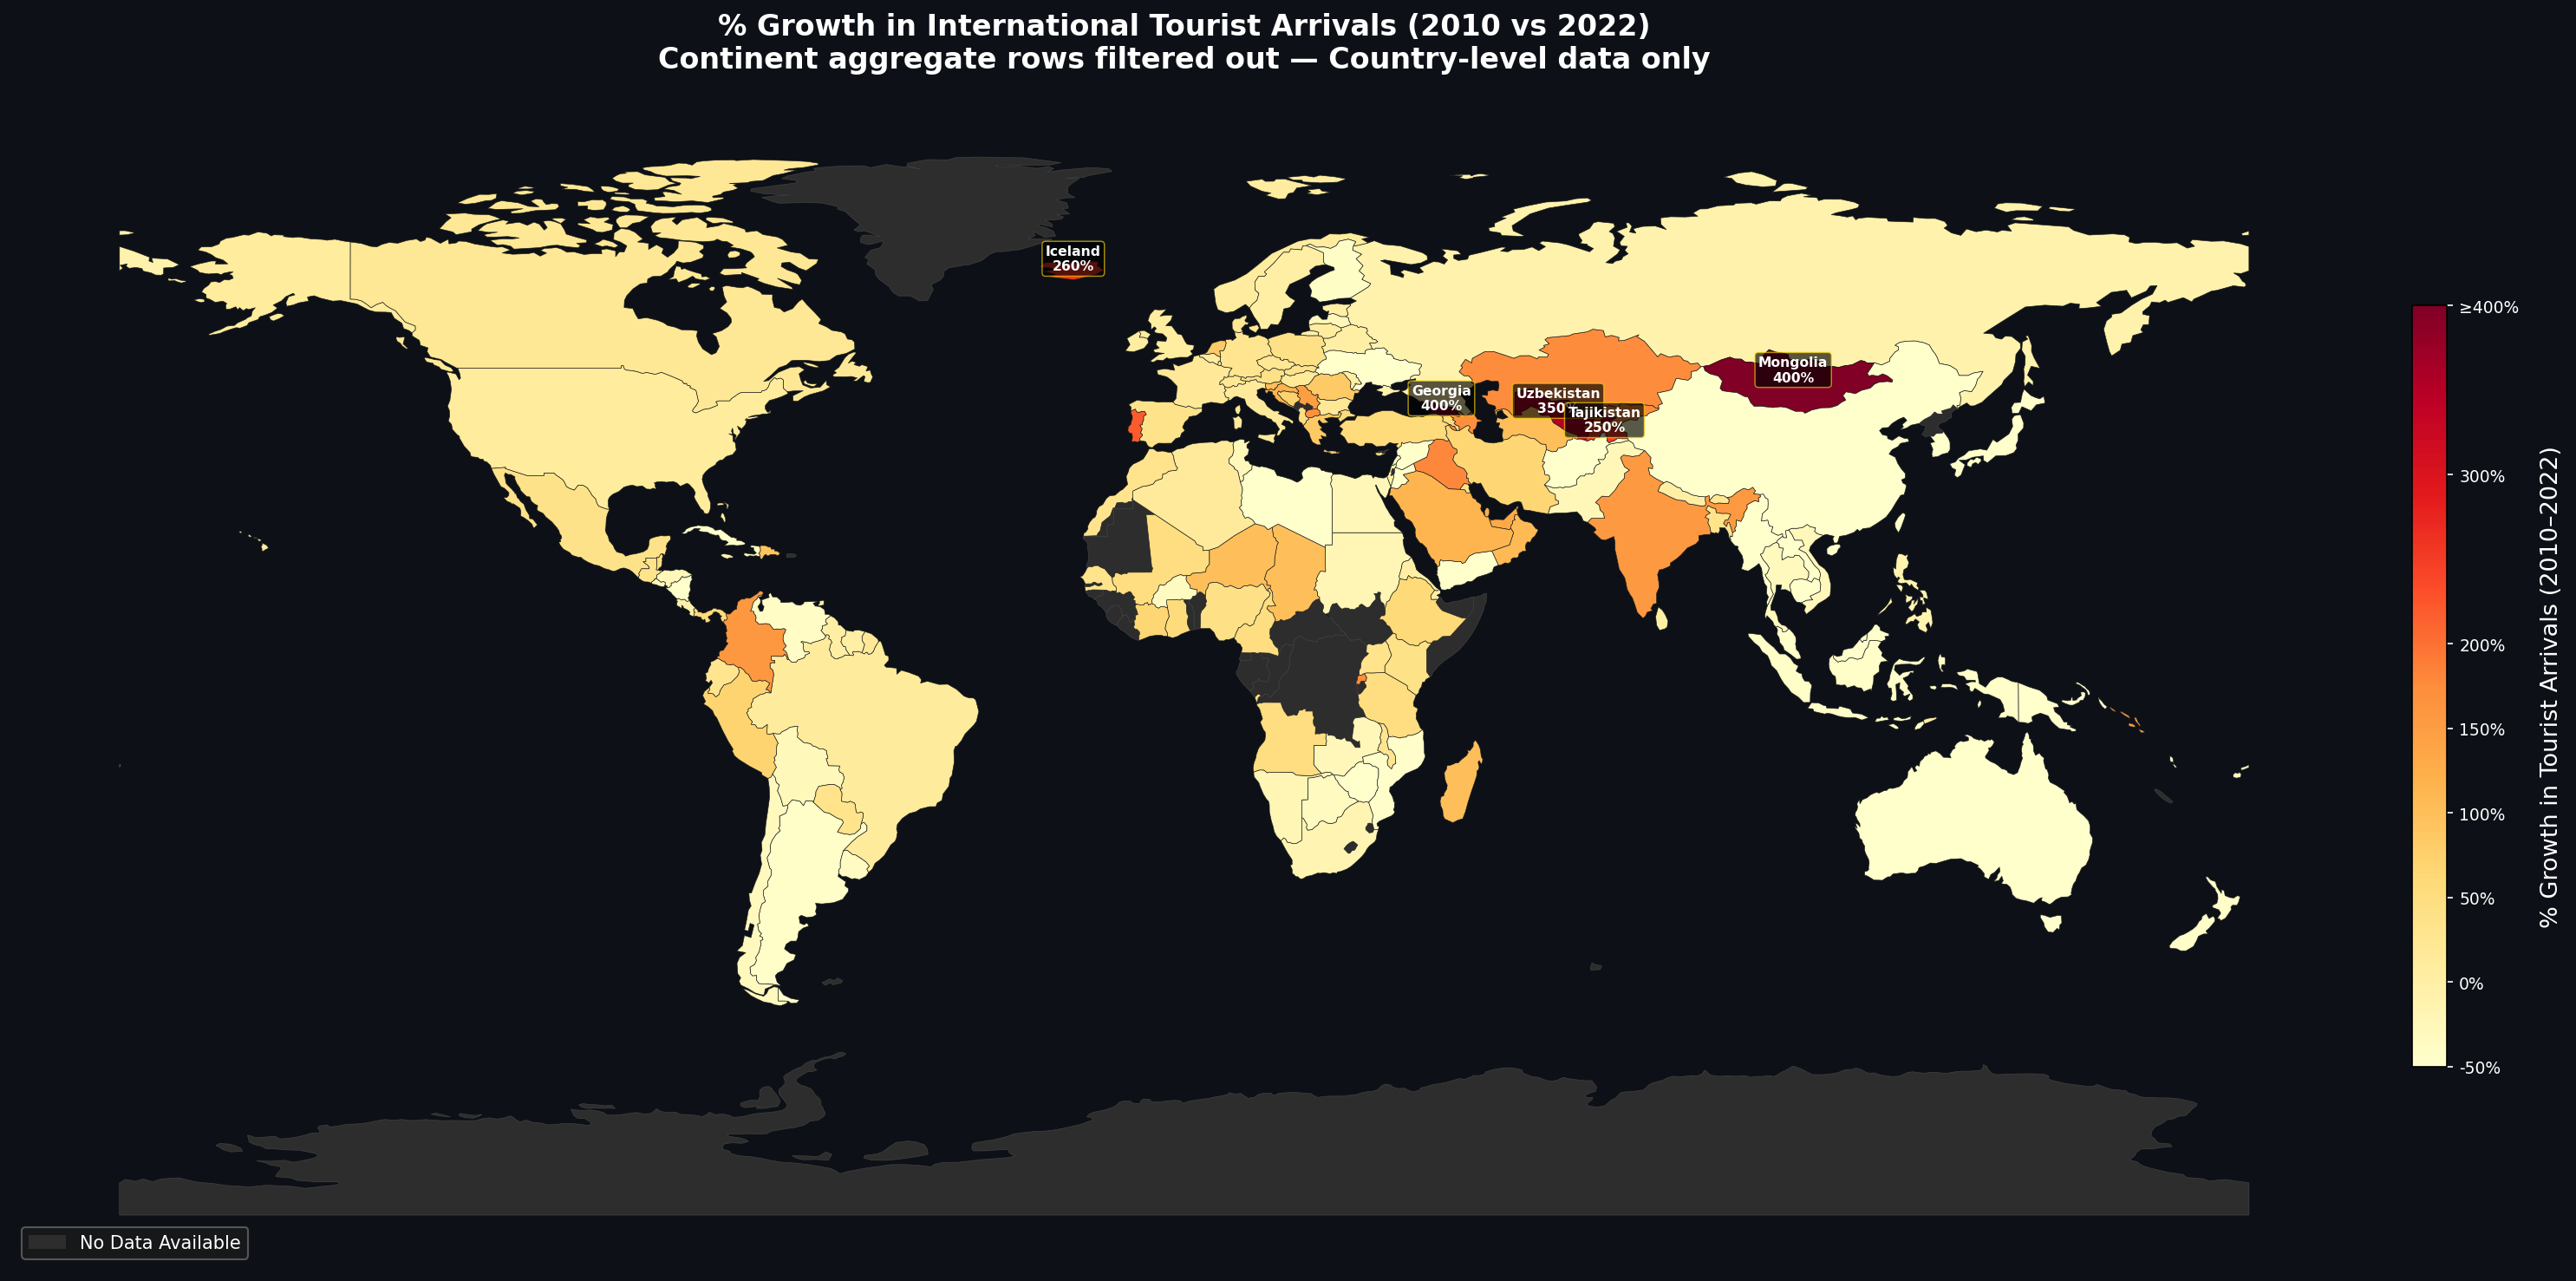

✅ Choropleth saved → choropleth_tourism_growth.png


In [ ]:
# ── CELL 5: MAIN OUTPUT — Choropleth Map ────────────────────

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patches as mpatches

# ───────────────────────────────────────────────────────────
# ✅ Load world map (GeoPandas >= 1.0 compatible)
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# ✅ Rename ISO column for merge
world = world.rename(columns={'ADM0_A3': 'ISO3'})

# ───────────────────────────────────────────────────────────
# Merge with your dataset
world_merged = world.merge(
    df_filtered[['ISO3', 'pct_growth_capped', 'pct_growth']],
    on='ISO3',
    how='left'
)

matched = world_merged['pct_growth_capped'].notna().sum()
print(f"✅ Countries matched to map geometry: {matched} / {len(df_filtered)}")

# ───────────────────────────────────────────────────────────
# Create figure
fig, ax = plt.subplots(1, 1, figsize=(22, 12))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

# Draw countries with NO data
world_merged[world_merged['pct_growth_capped'].isna()].plot(
    ax=ax,
    color='#2D2D2D',
    edgecolor='#444',
    linewidth=0.3
)

# Draw choropleth
world_merged[world_merged['pct_growth_capped'].notna()].plot(
    column='pct_growth_capped',
    ax=ax,
    cmap='YlOrRd',
    edgecolor='#1a1a1a',
    linewidth=0.3,
    vmin=-50,
    vmax=400,
    legend=False
)

# ───────────────────────────────────────────────────────────
# Colorbar
norm = Normalize(vmin=-50, vmax=400)
sm = ScalarMappable(cmap='YlOrRd', norm=norm)
sm._A = []

cbar = fig.colorbar(
    sm,
    ax=ax,
    shrink=0.5,
    aspect=22,
    pad=0.02,
    orientation='vertical'
)

cbar.set_label(
    '% Growth in Tourist Arrivals (2010–2022)',
    color='white',
    fontsize=13,
    labelpad=12
)

cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.get_yticklabels(), color='white', fontsize=9)

cbar.set_ticks([-50, 0, 50, 100, 150, 200, 300, 400])
cbar.set_ticklabels([
    '-50%', '0%', '50%', '100%', '150%',
    '200%', '300%', '≥400%'
])

# ───────────────────────────────────────────────────────────
# Annotate TOP 5 countries
top5 = df_filtered.nlargest(5, 'pct_growth')

world_top5 = world_merged[
    world_merged['ISO3'].isin(top5['ISO3'])
]

for _, row in world_top5.iterrows():
    if row.geometry is not None and not row.geometry.is_empty:
        centroid = row.geometry.centroid
        ax.annotate(
            f"{row['NAME'][:10]}\n{row['pct_growth']:.0f}%",
            xy=(centroid.x, centroid.y),
            fontsize=7.5,
            color='white',
            ha='center',
            fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.25',
                facecolor='black',
                alpha=0.65,
                edgecolor='#FFD700',
                linewidth=0.7
            )
        )

# ───────────────────────────────────────────────────────────
# Title
ax.set_title(
    '% Growth in International Tourist Arrivals (2010 vs 2022)\n'
    'Continent aggregate rows filtered out — Country-level data only',
    fontsize=16,
    color='white',
    fontweight='bold',
    pad=20
)

ax.set_axis_off()

# ───────────────────────────────────────────────────────────
# Legend
no_data_patch = mpatches.Patch(
    color='#2D2D2D',
    label='No Data Available'
)

ax.legend(
    handles=[no_data_patch],
    loc='lower left',
    facecolor='#1a1a1a',
    edgecolor='#666',
    labelcolor='white',
    fontsize=10
)

# ───────────────────────────────────────────────────────────
# Save & Show
plt.tight_layout()

plt.savefig(
    'choropleth_tourism_growth.png',
    dpi=200,
    bbox_inches='tight',
    facecolor='#0D1117'
)

plt.show()

print("✅ Choropleth saved → choropleth_tourism_growth.png")

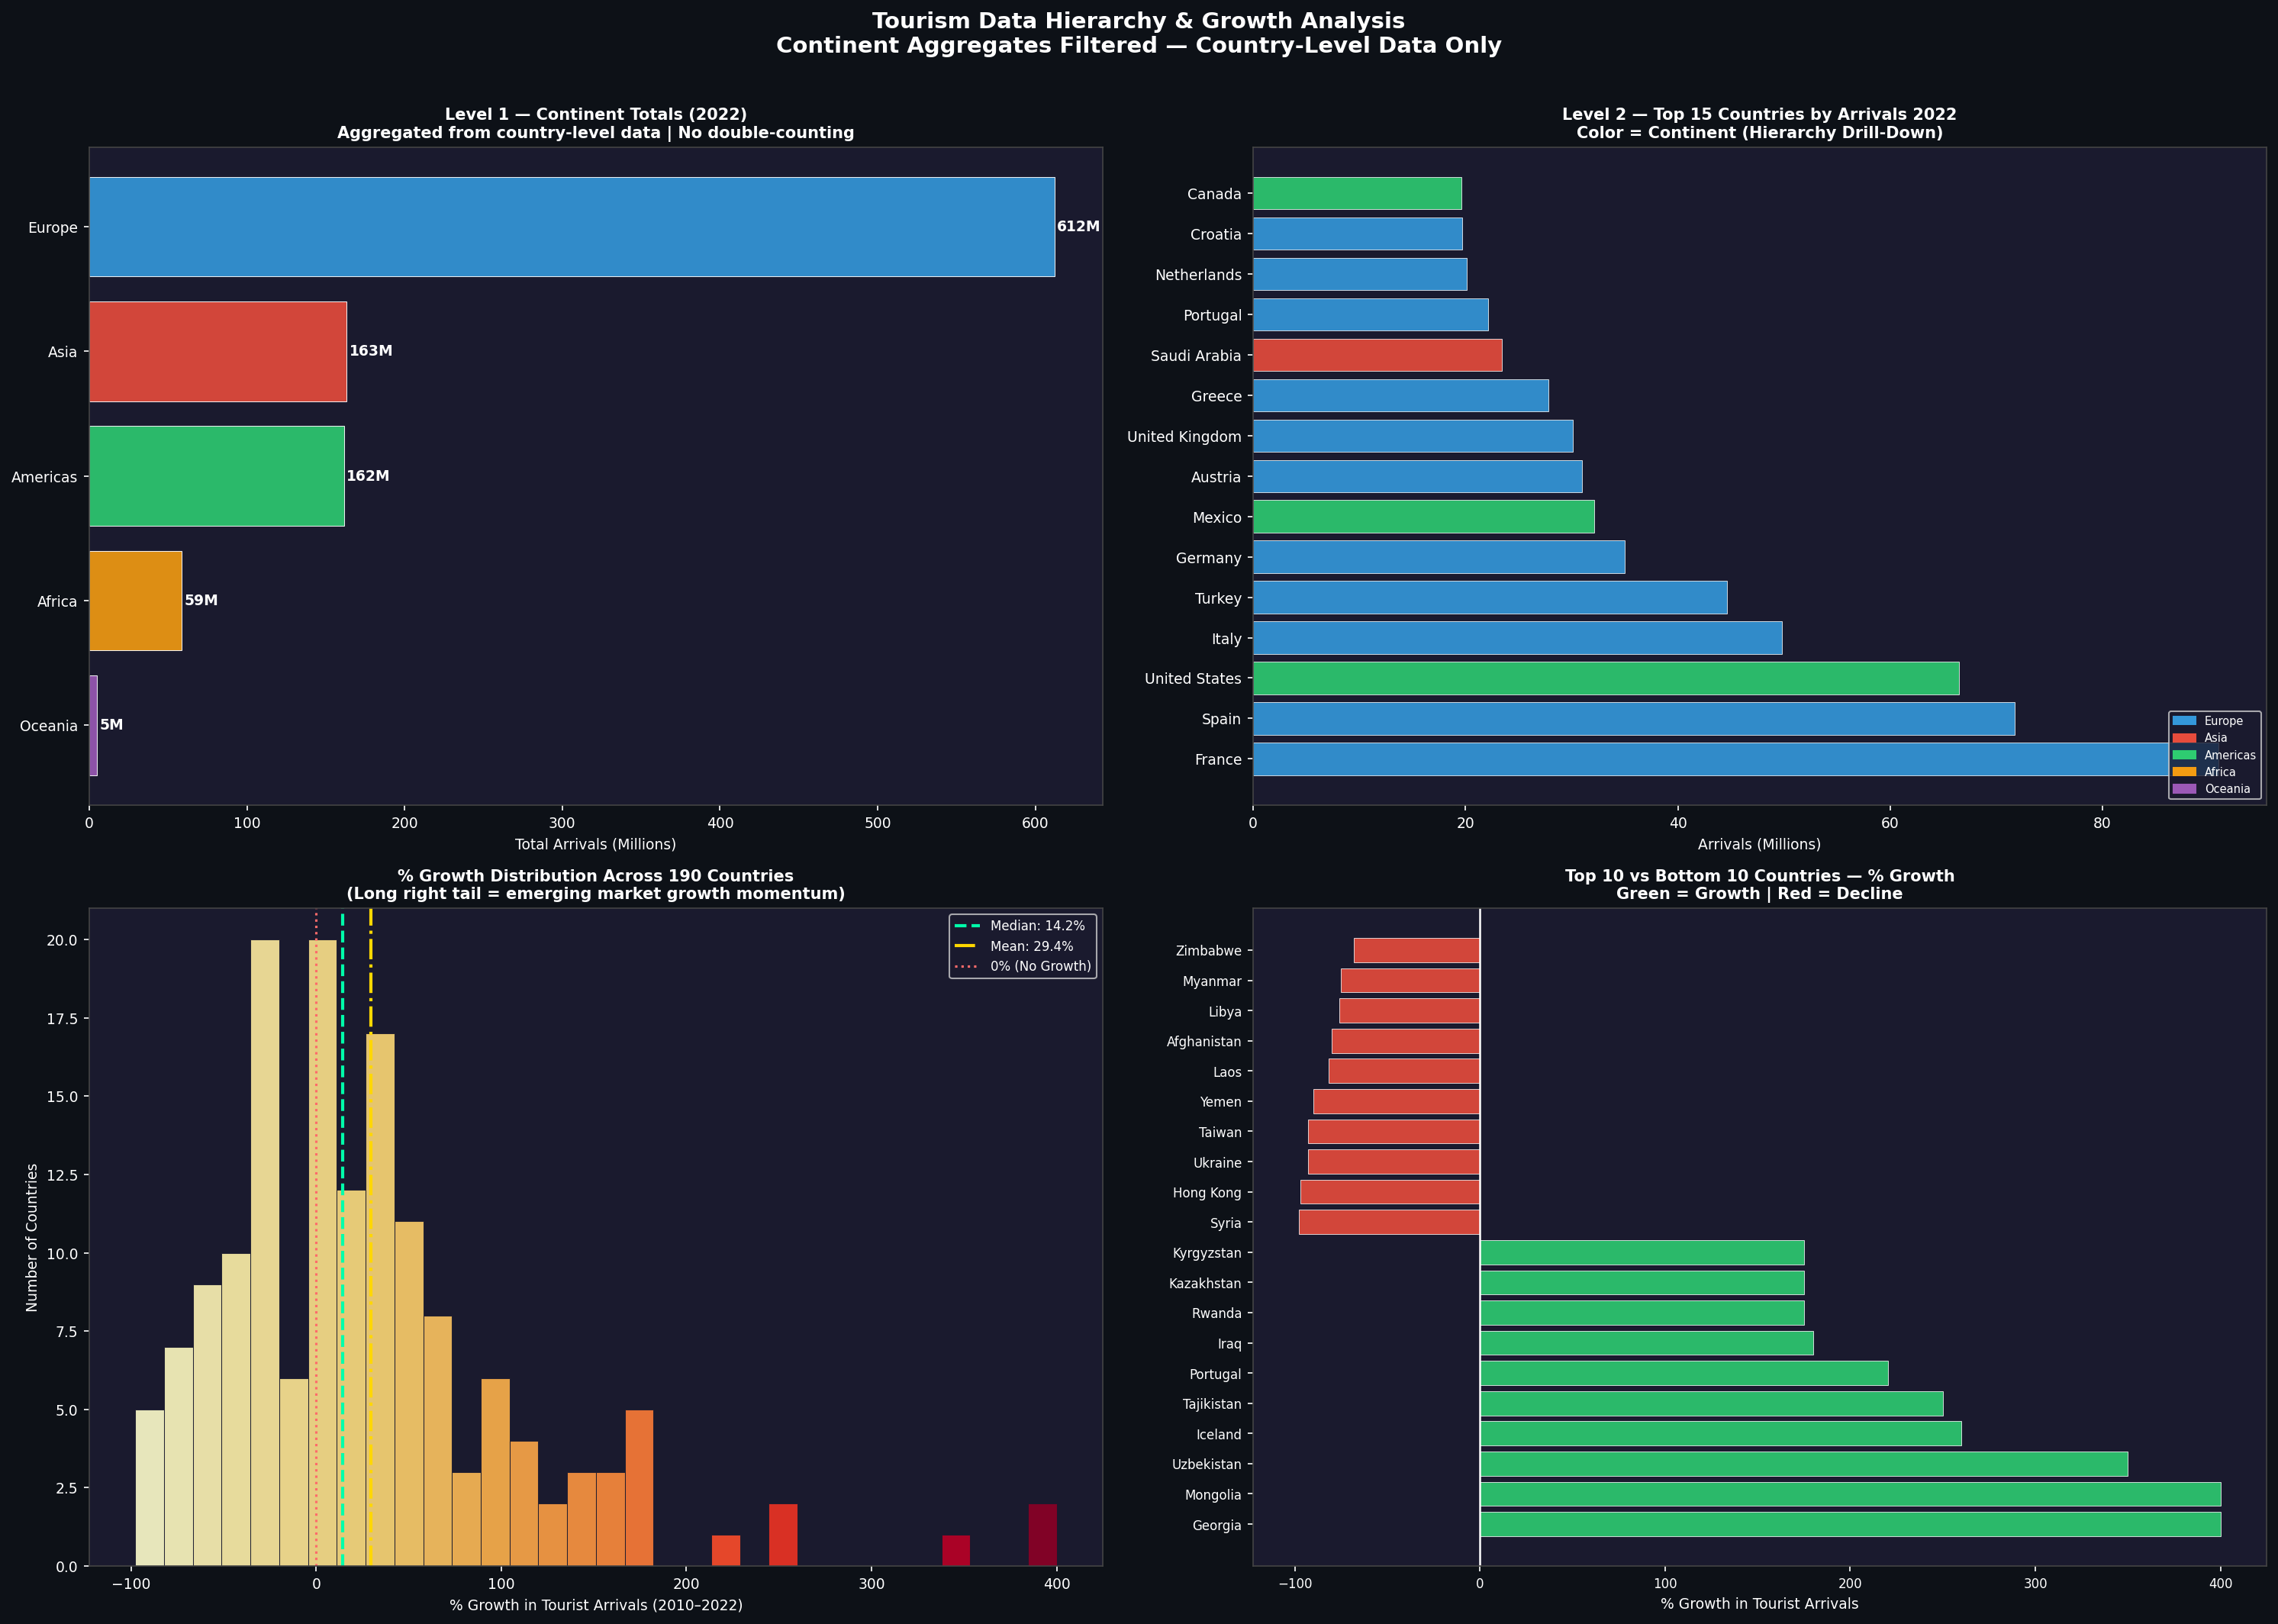

✅ Dashboard saved → tourism_hierarchy_analysis.png

📌 Instructions:
   1. Download both PNG files from Colab (Files panel on the left)
   2. Paste screenshots of each cell output into the Word document
   3. Also paste the PNG images into Section 5 placeholder boxes


In [ ]:
# ── CELL 6: Data Hierarchy Charts + Distribution Analysis ───

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.patch.set_facecolor('#0D1117')
fig.suptitle(
    'Tourism Data Hierarchy & Growth Analysis\n'
    'Continent Aggregates Filtered — Country-Level Data Only',
    color='white', fontsize=14, fontweight='bold', y=1.01)

colors_cont = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C']
cont_color_map = {
    'Europe':'#3498DB','Asia':'#E74C3C','Americas':'#2ECC71',
    'Africa':'#F39C12','Oceania':'#9B59B6'
}

# ─ Chart 1: Continent-level arrivals (Level 1 of hierarchy) ─
ax1 = axes[0, 0]
ax1.set_facecolor('#1a1a2e')
cont_summary = df_filtered.groupby('Continent')['arrivals_2022_M'].sum().sort_values()
bars = ax1.barh(cont_summary.index, cont_summary.values,
    color=[cont_color_map.get(c,'#95a5a6') for c in cont_summary.index],
    edgecolor='white', linewidth=0.5, alpha=0.9)
for bar, val in zip(bars, cont_summary.values):
    ax1.text(val + 1.5, bar.get_y() + bar.get_height()/2,
        f'{val:.0f}M', va='center', color='white', fontsize=9, fontweight='bold')
ax1.set_title('Level 1 — Continent Totals (2022)\nAggregated from country-level data | No double-counting',
    color='white', fontsize=10, fontweight='bold')
ax1.set_xlabel('Total Arrivals (Millions)', color='white', fontsize=9)
ax1.tick_params(colors='white', labelsize=9)
for spine in ax1.spines.values(): spine.set_color('#444')

# ─ Chart 2: Top 15 Countries (Level 2 drill-down) ─
ax2 = axes[0, 1]
ax2.set_facecolor('#1a1a2e')
top15 = df_filtered.nlargest(15, 'arrivals_2022_M')
bar_colors2 = [cont_color_map.get(c,'#95a5a6') for c in top15['Continent']]
ax2.barh(range(len(top15)), top15['arrivals_2022_M'].values,
    color=bar_colors2, edgecolor='white', linewidth=0.4, alpha=0.9)
ax2.set_yticks(range(len(top15)))
ax2.set_yticklabels(top15['Country'].values, color='white', fontsize=8)
ax2.set_title('Level 2 — Top 15 Countries by Arrivals 2022\nColor = Continent (Hierarchy Drill-Down)',
    color='white', fontsize=10, fontweight='bold')
ax2.set_xlabel('Arrivals (Millions)', color='white', fontsize=9)
ax2.tick_params(colors='white', labelsize=9)
for spine in ax2.spines.values(): spine.set_color('#444')
patches2 = [mpatches.Patch(color=v, label=k) for k,v in cont_color_map.items()]
ax2.legend(handles=patches2, loc='lower right', facecolor='#1a1a2e',
    labelcolor='white', fontsize=7, framealpha=0.8)

# ─ Chart 3: % Growth Distribution Histogram ─
ax3 = axes[1, 0]
ax3.set_facecolor('#1a1a2e')
valid_growth = df_filtered['pct_growth'].dropna()
valid_growth = valid_growth[valid_growth.between(-100, 400)]
n, bins, patches3 = ax3.hist(valid_growth, bins=32, edgecolor='#1a1a2e', linewidth=0.5, alpha=0.9)
# Color bars by value
cmap_hist = plt.cm.YlOrRd
norm_hist = Normalize(vmin=-100, vmax=400)
for patch, left_edge in zip(patches3, bins[:-1]):
    patch.set_facecolor(cmap_hist(norm_hist(left_edge)))
ax3.axvline(valid_growth.median(), color='#00FFAA', linewidth=2,
    linestyle='--', label=f'Median: {valid_growth.median():.1f}%')
ax3.axvline(valid_growth.mean(), color='#FFD700', linewidth=2,
    linestyle='-.', label=f'Mean: {valid_growth.mean():.1f}%')
ax3.axvline(0, color='#FF6B6B', linewidth=1.5, linestyle=':', label='0% (No Growth)')
ax3.set_title('% Growth Distribution Across 190 Countries\n(Long right tail = emerging market growth momentum)',
    color='white', fontsize=10, fontweight='bold')
ax3.set_xlabel('% Growth in Tourist Arrivals (2010–2022)', color='white', fontsize=9)
ax3.set_ylabel('Number of Countries', color='white', fontsize=9)
ax3.tick_params(colors='white', labelsize=9)
for spine in ax3.spines.values(): spine.set_color('#444')
ax3.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)

# ─ Chart 4: Top 10 vs Bottom 10 Growth ─
ax4 = axes[1, 1]
ax4.set_facecolor('#1a1a2e')
top10 = df_filtered.nlargest(10, 'pct_growth')[['Country','pct_growth']]
bot10 = df_filtered.nsmallest(10, 'pct_growth')[['Country','pct_growth']]
combined = pd.concat([top10, bot10]).reset_index(drop=True)
bar_colors4 = ['#2ECC71' if v >= 0 else '#E74C3C' for v in combined['pct_growth']]
ax4.barh(combined['Country'], combined['pct_growth'],
    color=bar_colors4, edgecolor='white', linewidth=0.4, alpha=0.9)
ax4.axvline(0, color='white', linewidth=1.2, linestyle='-')
ax4.set_title('Top 10 vs Bottom 10 Countries — % Growth\nGreen = Growth | Red = Decline',
    color='white', fontsize=10, fontweight='bold')
ax4.set_xlabel('% Growth in Tourist Arrivals', color='white', fontsize=9)
ax4.tick_params(colors='white', labelsize=8)
for spine in ax4.spines.values(): spine.set_color('#444')

plt.tight_layout()
plt.savefig('tourism_hierarchy_analysis.png', dpi=180,
    bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("✅ Dashboard saved → tourism_hierarchy_analysis.png")
print("\n📌 Instructions:")
print("   1. Download both PNG files from Colab (Files panel on the left)")
print("   2. Paste screenshots of each cell output into the Word document")
print("   3. Also paste the PNG images into Section 5 placeholder boxes")


In [ ]:
# ── CELL 7: Print Summary Statistics ────────────────────────

print("=" * 60)
print("  FINAL SUMMARY — TOURISM DATA HIERARCHY PROJECT")
print("=" * 60)
print(f"  Total countries analyzed:          {len(df_filtered)}")
print(f"  Continent rows removed (filter):   {df_all['Is_Continent'].sum()}")
print(f"  Year range:                        2010 – 2022")
print(f"  Growth metric:                     % Change in Arrivals")
print()
print(f"  Highest growth country:            {df_filtered.nlargest(1,'pct_growth')['Country'].values[0]}")
print(f"  Growth rate:                       {df_filtered['pct_growth'].max():.1f}%")
print()
print(f"  Biggest decline:                   {df_filtered.nsmallest(1,'pct_growth')['Country'].values[0]}")
print(f"  Decline rate:                      {df_filtered['pct_growth'].min():.1f}%")
print()
print(f"  Median % growth (190 countries):   {df_filtered['pct_growth'].median():.1f}%")
print(f"  Mean % growth:                     {df_filtered['pct_growth'].mean():.1f}%")
print(f"  Countries with positive growth:    {(df_filtered['pct_growth'] > 0).sum()}")
print(f"  Countries with negative growth:    {(df_filtered['pct_growth'] < 0).sum()}")
print("=" * 60)
print("  HOTS Goal: CREATION — Choropleth map with derived metric")
print("  Tool: Python (Matplotlib + Geopandas + Pandas + NumPy)")
print("=" * 60)

  FINAL SUMMARY — TOURISM DATA HIERARCHY PROJECT
  Total countries analyzed:          157
  Continent rows removed (filter):   6
  Year range:                        2010 – 2022
  Growth metric:                     % Change in Arrivals

  Highest growth country:            Georgia
  Growth rate:                       400.0%

  Biggest decline:                   Syria
  Decline rate:                      -97.6%

  Median % growth (190 countries):   14.2%
  Mean % growth:                     29.4%
  Countries with positive growth:    88
  Countries with negative growth:    58
  HOTS Goal: CREATION — Choropleth map with derived metric
  Tool: Python (Matplotlib + Geopandas + Pandas + NumPy)
